In [ ]:
# # Step 1 — Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [3]:
# Step 2 — Load the dataset

In [4]:
df = pd.read_csv(r"C:\Users\rainc\Downloads\Projects(intern)\Customer Segmentation\archive\Mall_Customers.csv")

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
print("Dataset shape",df.shape)

Dataset shape (200, 5)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
# step 3 - Dispaly colum names

In [10]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
CustomerID
Gender
Age
Annual Income (k$)
Spending Score (1-100)


In [11]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [12]:
# check missing values

In [13]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [14]:
# Data preprocessing

In [15]:
# step 4  Handling missing values

In [16]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [17]:
# fill numerical missing values using median

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column]=df[column].fillna(df[column].median())

In [19]:
categorical_columns=df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] =df[column].fillna(df[column].mode()[0])

In [20]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [21]:
# Remove Irrelevant Identifier

In [22]:
# Step 5 — Remove identifier column

In [23]:
df_model = df.drop(columns=["CustomerID"])

df_model.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [24]:
# Encode Gender

In [25]:
# Step 6 — Encode gender

In [26]:
df_model["Gender"] = df_model["Gender"].map({
    "Male": 0,
    "Female": 1
})

df_model.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [27]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [28]:
# Exploratory Data Analysis

In [29]:
# Step 7 — Age distribution

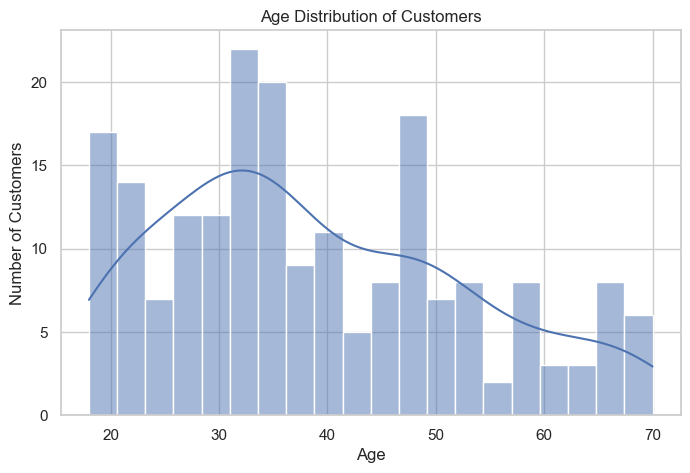

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [31]:
# Annual Income Distribution

In [32]:
# Step 8 — Annual income distribution

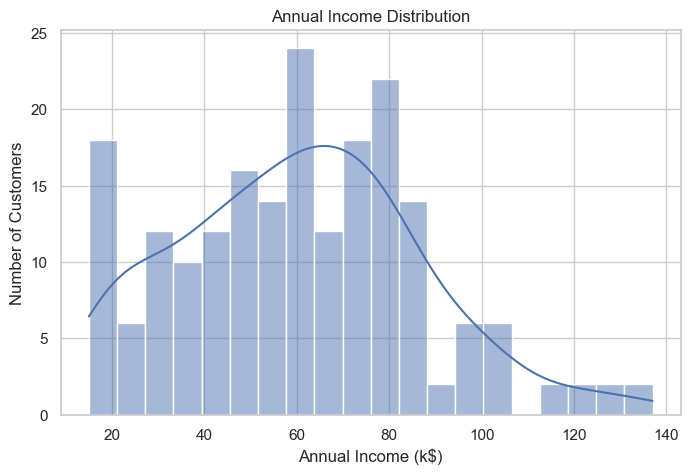

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Annual Income (k$)"],
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

In [34]:
# Spending Score Distribution

In [35]:
# Step 9 — Spending score distribution

<function matplotlib.pyplot.show(close=None, block=None)>

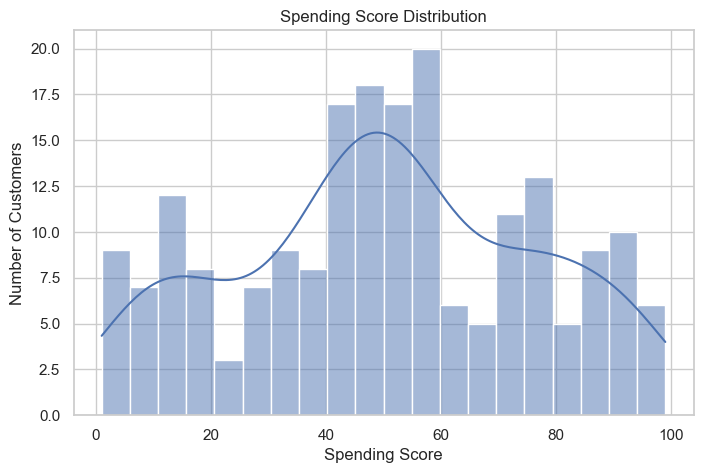

In [36]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Spending Score (1-100)"],
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show

In [37]:
# Step 10 — Gender distribution

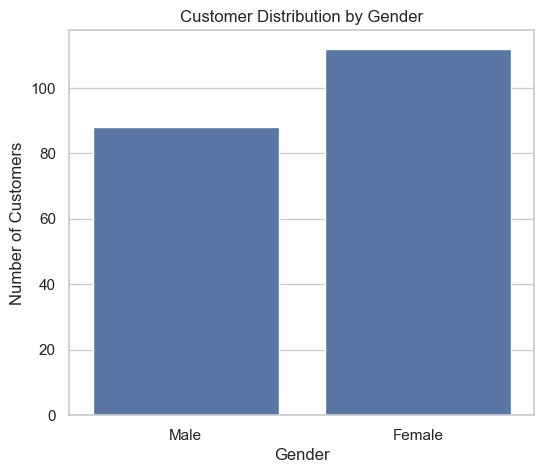

In [38]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

In [39]:
# Age vs Spending Score

In [40]:
# Step 11 — Age vs spending score

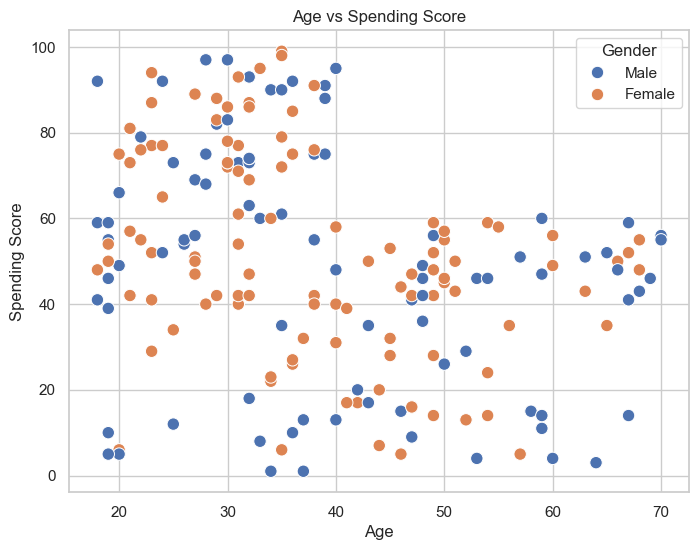

In [41]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Gender",
    s=80
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

In [42]:
# Income vs Spending Score

In [43]:
# Step 12 — Annual income vs spending score

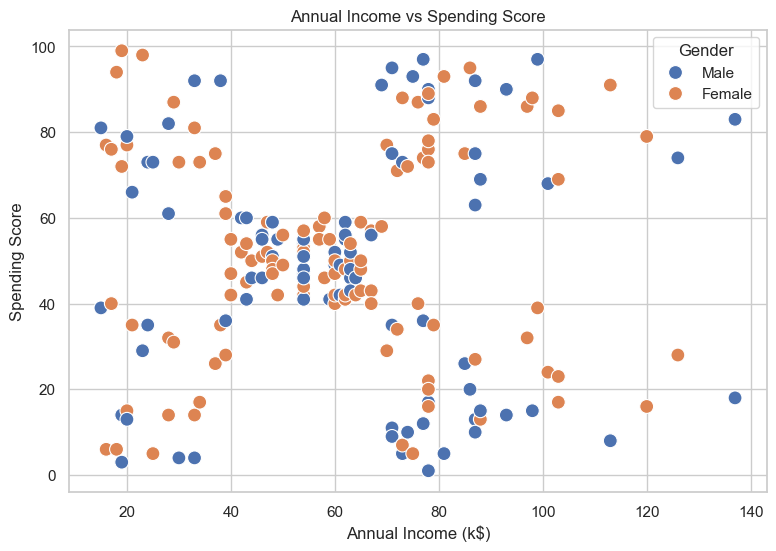

In [44]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    s=100
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

In [45]:
# Correlation Heatmap

In [46]:
# Step 13 — Correlation heatmap

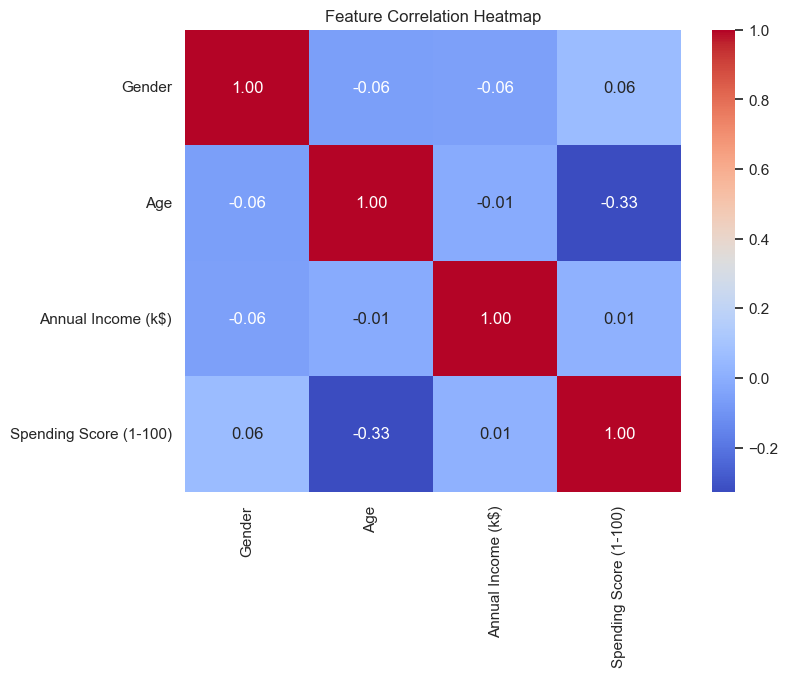

In [47]:
plt.figure(figsize=(8, 6))

correlation = df_model.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [48]:
# Select Features for Clustering

In [49]:
# Step 14 — Select clustering features

In [50]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [51]:
# Normalize the Features

In [52]:
# Step 15 — Standardize numerical features

In [53]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [54]:
# Determine Optimal Number of Clusters

In [55]:
# Step 16 — Elbow method

In [56]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

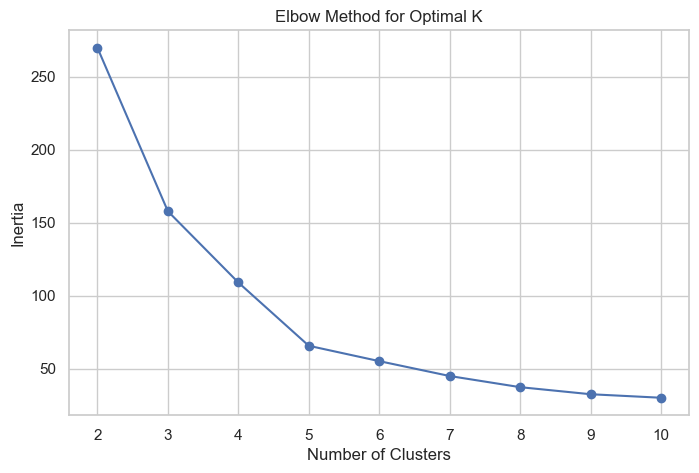

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.show()

In [58]:
# Step 17 — Calculate silhouette scores

In [59]:

silhouette_scores = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.3213
K = 3: Silhouette Score = 0.4666
K = 4: Silhouette Score = 0.4939
K = 5: Silhouette Score = 0.5547
K = 6: Silhouette Score = 0.5399
K = 7: Silhouette Score = 0.5281
K = 8: Silhouette Score = 0.4552
K = 9: Silhouette Score = 0.4571
K = 10: Silhouette Score = 0.4432


In [60]:
# Train Final K-Means Model

In [61]:
# Step 18 — Apply K-Means clustering

In [62]:
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [63]:
# Step 19 — Cluster distribution

In [64]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


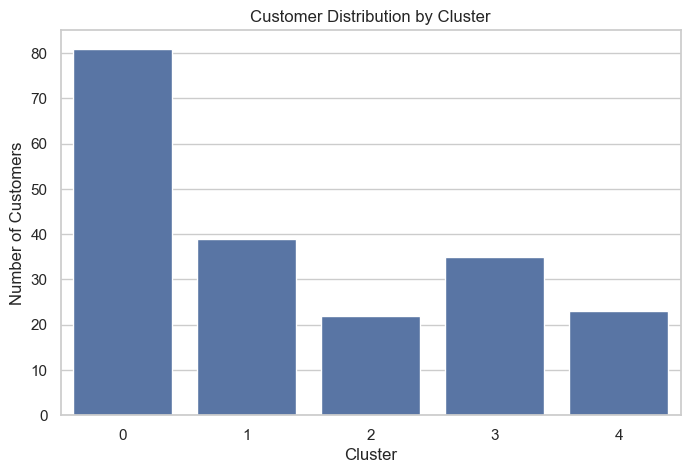

In [65]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title("Customer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

In [66]:
# Step 20 — Customer segmentation visualization

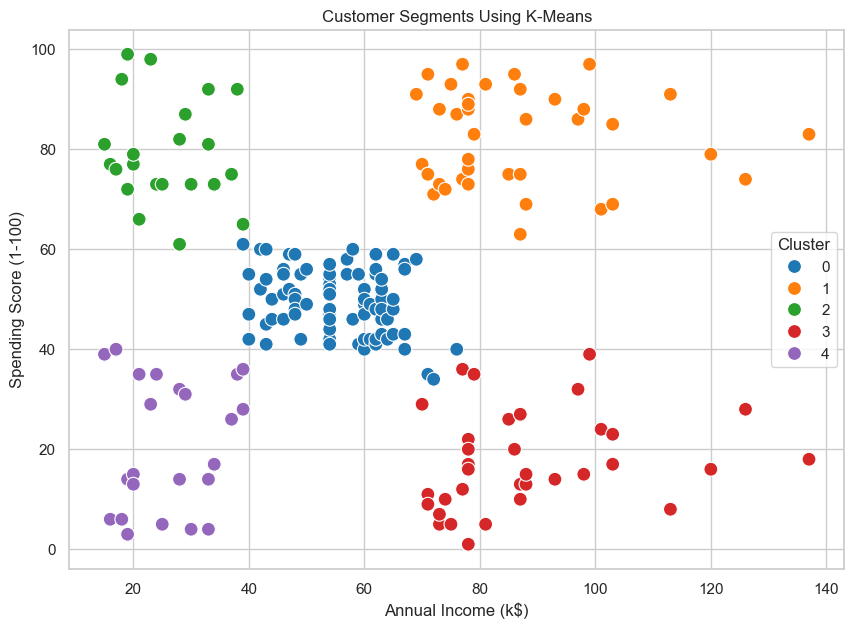

In [67]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=100
)

plt.title("Customer Segments Using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")

plt.show()

In [68]:
# Step 21 — Calculate cluster centers in original scale

In [69]:
centers_scaled = kmeans.cluster_centers_

centers = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(
    centers,
    columns=[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

centers_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


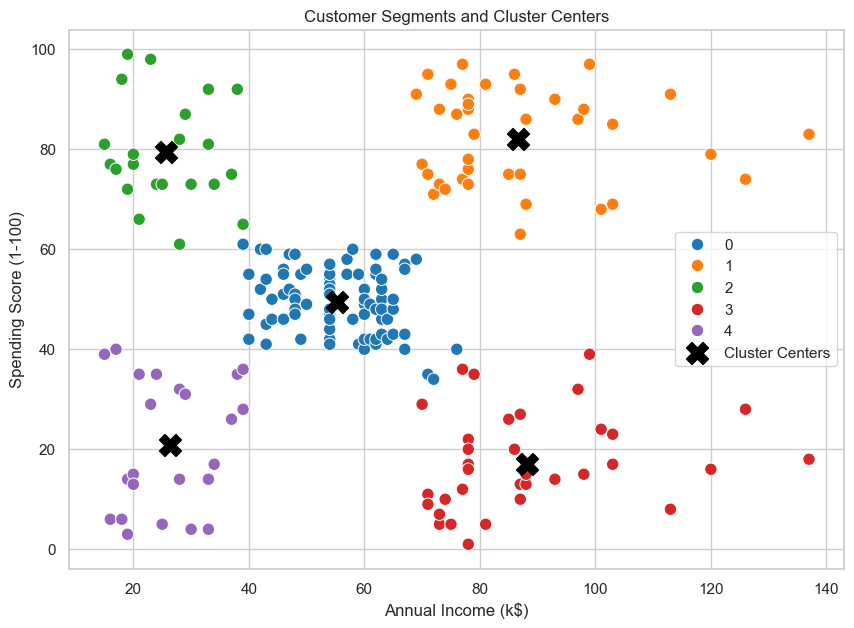

In [70]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    c="black",
    label="Cluster Centers"
)

plt.title("Customer Segments and Cluster Centers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

In [71]:
# Step 22 — Cluster profiling

In [72]:
cluster_profile = df.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
}).round(2)

cluster_profile.rename(
    columns={
        "CustomerID": "Customer Count"
    },
    inplace=True
)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


In [73]:
# Step 23 — Gender distribution within clusters

In [74]:
gender_cluster = pd.crosstab(
    df["Cluster"],
    df["Gender"]
)

gender_cluster

Gender,Female,Male
Cluster,,
0,48,33
1,21,18
2,13,9
3,16,19
4,14,9


In [75]:
gender_percentage = pd.crosstab(
    df["Cluster"],
    df["Gender"],
    normalize="index"
).round(3) * 100

gender_percentage

Gender,Female,Male
Cluster,,
0,59.3,40.7
1,53.8,46.2
2,59.1,40.9
3,45.7,54.3
4,60.9,39.1


In [76]:
# Step 24 — PCA visualization

In [77]:
pca_features = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

pca_scaled = StandardScaler().fit_transform(pca_features)

pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(pca_scaled)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["Cluster"].values

pca_df.head()

,PC1,PC2,Cluster
0,-0.615720,-1.763481,4
1,-1.665793,-1.820747,2
2,0.337862,-1.674799,4
3,-1.456573,-1.772430,2
4,-0.038465,-1.662740,4


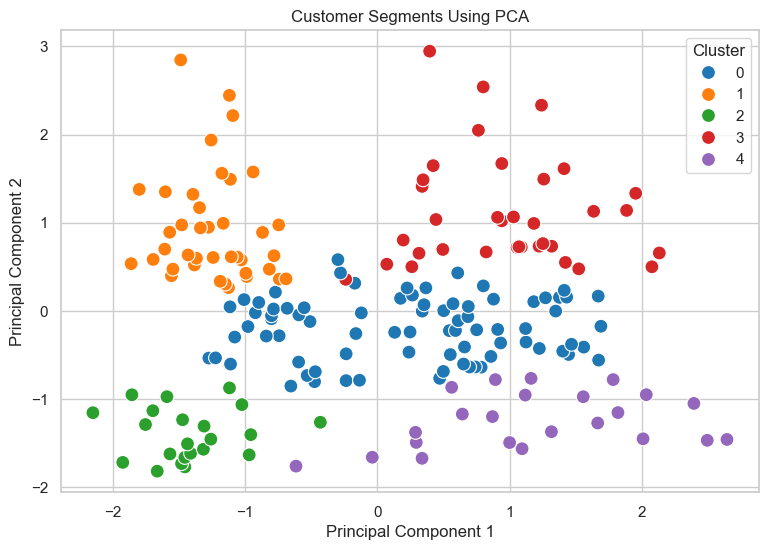

In [78]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=100
)

plt.title("Customer Segments Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [79]:
# Step 25 — Final silhouette score

In [80]:
final_silhouette = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print(
    f"Final Silhouette Score: {final_silhouette:.4f}"
)

Final Silhouette Score: 0.5547


In [81]:
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


In [82]:
# Step 26 — Assign business-friendly segment names

In [83]:

segment_names = {
    0: "Standard Customers",
    1: "High-Value Customers",
    2: "Careful Spenders",
    3: "Premium Low-Spending Customers",
    4: "Young High-Spending Customers"
}

df["Customer Segment"] = df["Cluster"].map(segment_names)

df[
    [
        "CustomerID",
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)",
        "Cluster",
        "Customer Segment"
    ]
].head(10)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,19,15,39,4,Young High-Spending Customers
1,2,21,15,81,2,Careful Spenders
2,3,20,16,6,4,Young High-Spending Customers
3,4,23,16,77,2,Careful Spenders
4,5,31,17,40,4,Young High-Spending Customers
5,6,22,17,76,2,Careful Spenders
6,7,35,18,6,4,Young High-Spending Customers
7,8,23,18,94,2,Careful Spenders
8,9,64,19,3,4,Young High-Spending Customers
9,10,30,19,72,2,Careful Spenders


In [84]:
# Step 27 — Final customer segmentation dataset

In [85]:

final_df = df[
    [
        "CustomerID",
        "Gender",
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)",
        "Cluster",
        "Customer Segment"
    ]
]

final_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,4,Young High-Spending Customers
1,2,Male,21,15,81,2,Careful Spenders
2,3,Female,20,16,6,4,Young High-Spending Customers
3,4,Female,23,16,77,2,Careful Spenders
4,5,Female,31,17,40,4,Young High-Spending Customers


In [86]:
final_df.to_csv(
    "customer_segments.csv",
    index=False
)

print("Customer segmentation file saved successfully.")

Customer segmentation file saved successfully.
